# 🩺 Framingham Heart Study — Part II: Model Training & Evaluation

**10-Year Coronary Heart Disease Risk Prediction**

---

## Sections
- **Section 4** — Feature Preparation, Model Training & Evaluation
- **Section 5** — SHAP Explainability, Model Export & Deployment Preparation

## Methodology
| Decision | Choice | Reason |
|----------|--------|---------|
| Missing values | KNN Imputer (k=5, distance-weighted) | Preserves inter-feature relationships |
| Normalization | PowerTransformer (Yeo-Johnson) | Corrects skewed distributions in medical data |
| Class imbalance | Class weights | No synthetic data; industry standard for fraud/medical AI |
| Split strategy | Stratified 80/20 — **split first** | Prevents data leakage |
| Tuning | Optuna Bayesian optimization (50 trials) | Efficient hyperparameter search |
| Ensemble | Soft-voting (LR + RF + XGBoost + CatBoost) | Diverse learners, averaged probabilities |
| Primary metrics | **Sensitivity + PR-AUC** | Right choice for severely imbalanced medical data |
| SHAP | XGBoost (best tuned tree model) | Direct tree explainability |

## Section 4 — Feature Preparation, Model Training & Evaluation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import warnings
from datetime import datetime

warnings.filterwarnings('ignore')

from sklearn.impute import KNNImputer
from sklearn.preprocessing import PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import optuna

from sklearn.metrics import (
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    confusion_matrix, classification_report,
    f1_score, precision_score, recall_score,
    accuracy_score, balanced_accuracy_score
)

import shap

plt.style.use('seaborn-v0_8')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 5)

print(' Libraries loaded')
print(f'   Started: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')

✅ Libraries loaded
   Started: 2026-02-28 12:08:45


### 4.1 Load Data

In [2]:
df = pd.read_csv('../data/framingham_heart_study.csv')

print(f'Shape: {df.shape}')
vc = df['TenYearCHD'].value_counts()
print(f'\nTarget distribution:')
print(f'  No CHD (0): {vc[0]:,}  ({vc[0]/len(df)*100:.1f}%)')
print(f'  CHD    (1): {vc[1]:,}  ({vc[1]/len(df)*100:.1f}%)')
print(f'  Imbalance:  {vc[0]/vc[1]:.1f}:1')
print(f'\nMissing values:')
missing = df.isnull().sum()
print(missing[missing > 0].to_string())

Shape: (4240, 16)

Target distribution:
  No CHD (0): 3,596  (84.8%)
  CHD    (1): 644  (15.2%)
  Imbalance:  5.6:1

Missing values:
education     105
cigsPerDay     29
BPMeds         53
totChol        50
BMI            19
heartRate       1
glucose       388


### 4.2 Prepare Features & Target

In [3]:
X = df.drop('TenYearCHD', axis=1).copy()
y = df['TenYearCHD']

X['pulse_pressure'] = X['sysBP'] - X['diaBP']

def pack_years(row):
    if row['currentSmoker'] == 1 and pd.notna(row['cigsPerDay']):
        return (row['cigsPerDay'] / 20) * max(0, row['age'] - 18)
    return 0.0

X['pack_years'] = X.apply(pack_years, axis=1)

print(f'Features: {X.shape[1]}  (15 original + 2 clinical)')
print(f'All features: {list(X.columns)}')

Features: 17  (15 original + 2 clinical)
All features: ['male', 'age', 'education', 'currentSmoker', 'cigsPerDay', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose', 'pulse_pressure', 'pack_years']


### 4.3 Stratified Train / Test Split
> Split happens **first** — before imputation, balancing, or any fitting.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Stratified 80/20 split')
print(f'  Train: {len(X_train):,}  CHD={y_train.sum()} ({y_train.mean()*100:.1f}%)')
print(f'  Test:  {len(X_test):,}   CHD={y_test.sum()} ({y_test.mean()*100:.1f}%)')
print(f'\n   Class ratio preserved in both sets')

Stratified 80/20 split
  Train: 3,392  CHD=515 (15.2%)
  Test:  848   CHD=129 (15.2%)

  ✅ Class ratio preserved in both sets


### 4.4 Preprocessing Pipeline
- **Continuous** (≥ 10 unique values): KNN Impute → PowerTransform  
- **Categorical / binary**: KNN Impute only  
- Pipeline fit on **train only**, then applied to both

In [5]:
continuous_features  = [c for c in X.columns if X[c].nunique() >= 10]
categorical_features = [c for c in X.columns if c not in continuous_features]

print(f'Continuous  ({len(continuous_features)}): {continuous_features}')
print(f'Categorical ({len(categorical_features)}): {categorical_features}')

preprocessor = ColumnTransformer([
    ('cont', Pipeline([
        ('impute', KNNImputer(n_neighbors=5, weights='distance')),
        ('scale',  PowerTransformer(method='yeo-johnson'))
    ]), continuous_features),
    ('cat', Pipeline([
        ('impute', KNNImputer(n_neighbors=5, weights='distance'))
    ]), categorical_features)
])

X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep  = preprocessor.transform(X_test)

feature_names = continuous_features + categorical_features

X_train_prep = pd.DataFrame(X_train_prep, columns=feature_names)
X_test_prep  = pd.DataFrame(X_test_prep,  columns=feature_names)

print(f'\n Preprocessed')
print(f'   Train shape: {X_train_prep.shape}')
print(f'   Test  shape: {X_test_prep.shape}')
print(f'   Missing remaining: {X_train_prep.isnull().sum().sum()}')

Continuous  (10): ['age', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose', 'pulse_pressure', 'pack_years']
Categorical (7): ['male', 'education', 'currentSmoker', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes']



✅ Preprocessed
   Train shape: (3392, 17)
   Test  shape: (848, 17)
   Missing remaining: 0


### 4.5 Class Imbalance Check

In [6]:
minority_pct = y_train.mean()
pos_weight   = (y_train == 0).sum() / (y_train == 1).sum()

print(f'Minority class: {minority_pct*100:.1f}%')
print(f'Positive class weight: {pos_weight:.2f}')

if minority_pct < 0.30:
    print('\n  Severe imbalance (<30%) — using class weights for all models')
    print('   Class weights penalise misclassifying the minority class during training')
    print('   No synthetic data (SMOTE) needed — avoids overfitting risk')
else:
    print('\n Moderate imbalance — class weights sufficient')

X_train_balanced = X_train_prep
y_train_balanced = y_train.reset_index(drop=True)

Minority class: 15.2%
Positive class weight: 5.59

⚠️  Severe imbalance (<30%) — using class weights for all models
   Class weights penalise misclassifying the minority class during training
   No synthetic data (SMOTE) needed — avoids overfitting risk


### 4.6 Optuna Hyperparameter Tuning — XGBoost

In [7]:
optuna.logging.set_verbosity(optuna.logging.WARNING)
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def objective_xgb(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 100, 500),
        'max_depth':        trial.suggest_int('max_depth', 3, 8),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma':            trial.suggest_float('gamma', 0, 5),
        'scale_pos_weight': pos_weight,
        'random_state':     42,
        'eval_metric':      'logloss'
    }
    model = XGBClassifier(**params)
    return cross_val_score(
        model, X_train_balanced, y_train_balanced,
        cv=cv_strategy, scoring='roc_auc'
    ).mean()

print(' Tuning XGBoost — 50 Optuna trials ...')
study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=50, show_progress_bar=True)
best_params_xgb = study_xgb.best_params

print(f'\n Best XGBoost ROC-AUC (CV): {study_xgb.best_value:.4f}')
print('   Best parameters:')
for k, v in best_params_xgb.items():
    print(f'     {k:20s}: {v}')

🔍 Tuning XGBoost — 50 Optuna trials ...


  0%|          | 0/50 [00:00<?, ?it/s]


✅ Best XGBoost ROC-AUC (CV): 0.7211
   Best parameters:
     n_estimators        : 150
     max_depth           : 3
     learning_rate       : 0.015210183435926094
     subsample           : 0.6094632439026828
     colsample_bytree    : 0.7492755934318234
     gamma               : 4.234261030540944


### 4.7 Optuna Hyperparameter Tuning — CatBoost

In [8]:
def objective_cat(trial):
    params = {
        'iterations':    trial.suggest_int('iterations', 100, 500),
        'depth':         trial.suggest_int('depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'l2_leaf_reg':   trial.suggest_float('l2_leaf_reg', 1e-3, 10, log=True),
        'auto_class_weights': 'Balanced',
        'random_state':  42,
        'verbose':       0
    }
    model = CatBoostClassifier(**params)
    return cross_val_score(
        model, X_train_balanced, y_train_balanced,
        cv=cv_strategy, scoring='roc_auc'
    ).mean()

print(' Tuning CatBoost — 50 Optuna trials ...')
study_cat = optuna.create_study(direction='maximize')
study_cat.optimize(objective_cat, n_trials=50, show_progress_bar=True)
best_params_cat = study_cat.best_params
best_params_cat['auto_class_weights'] = 'Balanced'
best_params_cat['random_state'] = 42
best_params_cat['verbose'] = 0

print(f'\n Best CatBoost ROC-AUC (CV): {study_cat.best_value:.4f}')
print('   Best parameters:')
for k, v in best_params_cat.items():
    print(f'     {k:20s}: {v}')

🔍 Tuning CatBoost — 50 Optuna trials ...


  0%|          | 0/50 [00:00<?, ?it/s]


✅ Best CatBoost ROC-AUC (CV): 0.7294
   Best parameters:
     iterations          : 120
     depth               : 3
     learning_rate       : 0.07772767051424104
     l2_leaf_reg         : 0.15062587385772375
     auto_class_weights  : Balanced
     random_state        : 42
     verbose             : 0


### 4.8 Initialise Models

In [9]:
xgb_model = XGBClassifier(
    **best_params_xgb,
    scale_pos_weight=pos_weight,
    random_state=42,
    eval_metric='logloss'
)
print(' XGBoost  (Optuna-tuned)')

cat_model = CatBoostClassifier(**best_params_cat)
print(' CatBoost (Optuna-tuned)')

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42
)
print(' Random Forest (class-balanced)')

lr_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)
print(' Logistic Regression (class-balanced)')

ensemble_model = VotingClassifier(
    estimators=[
        ('lr',  lr_model),
        ('rf',  rf_model),
        ('xgb', xgb_model),
        ('cat', cat_model)
    ],
    voting='soft'
)
print(' Ensemble  (Soft Voting: LR + RF + XGBoost + CatBoost)')

models = {
    'Logistic Regression': lr_model,
    'Random Forest':        rf_model,
    'XGBoost':              xgb_model,
    'CatBoost':             cat_model,
    'Ensemble':             ensemble_model
}

✅ XGBoost  (Optuna-tuned)
✅ CatBoost (Optuna-tuned)
✅ Random Forest (class-balanced)
✅ Logistic Regression (class-balanced)
✅ Ensemble  (Soft Voting: LR + RF + XGBoost + CatBoost)


### 4.9 Cross-Validation (5-Fold Stratified)

In [10]:
print('5-Fold Stratified Cross-Validation — ROC-AUC\n')

cv_results = {}
for name, model in models.items():
    scores = cross_val_score(
        model, X_train_balanced, y_train_balanced,
        cv=cv_strategy, scoring='roc_auc'
    )
    cv_results[name] = scores
    print(f'  {name:22s}: {scores.mean():.4f}  ±  {scores.std()*2:.4f}')

5-Fold Stratified Cross-Validation — ROC-AUC

  Logistic Regression   : 0.7273  ±  0.0611


  Random Forest         : 0.7107  ±  0.0505


  XGBoost               : 0.7211  ±  0.0612


  CatBoost              : 0.7294  ±  0.0645


  Ensemble              : 0.7282  ±  0.0622


### 4.10 Train Final Models

In [11]:
print('Training final models on full training set ...\n')
for name, model in models.items():
    model.fit(X_train_balanced, y_train_balanced)
    print(f'   {name}')
print('\n All models trained')

Training final models on full training set ...

  ✅ Logistic Regression


  ✅ Random Forest
  ✅ XGBoost
  ✅ CatBoost


  ✅ Ensemble

✅ All models trained


### 4.11 Evaluate on Test Set

In [12]:
y_test_reset = y_test.reset_index(drop=True)

predictions  = {}
probabilities = {}

for name, model in models.items():
    predictions[name]   = model.predict(X_test_prep)
    probabilities[name] = model.predict_proba(X_test_prep)[:, 1]

results_df = pd.DataFrame()
for name in models:
    y_pred  = predictions[name]
    y_proba = probabilities[name]
    results_df.loc[name, 'ROC-AUC']   = roc_auc_score(y_test_reset, y_proba)
    results_df.loc[name, 'PR-AUC']    = average_precision_score(y_test_reset, y_proba)
    results_df.loc[name, 'Accuracy']  = accuracy_score(y_test_reset, y_pred)
    results_df.loc[name, 'Precision'] = precision_score(y_test_reset, y_pred)
    results_df.loc[name, 'Recall']    = recall_score(y_test_reset, y_pred)
    results_df.loc[name, 'F1-Score']  = f1_score(y_test_reset, y_pred)

results_df = results_df.round(4)
print('\nTest-set performance (sorted by PR-AUC):')
print(results_df.sort_values('PR-AUC', ascending=False).to_string())


Test-set performance (sorted by PR-AUC):
                     ROC-AUC  PR-AUC  Accuracy  Precision  Recall  F1-Score
Logistic Regression   0.6992  0.3045    0.6616     0.2468  0.5969    0.3492
Ensemble              0.6866  0.3005    0.7052     0.2590  0.5039    0.3421
XGBoost               0.6835  0.2939    0.6580     0.2476  0.6124    0.3527
CatBoost              0.6912  0.2877    0.6627     0.2492  0.6047    0.3529
Random Forest         0.6491  0.2717    0.8019     0.3030  0.2326    0.2632


In [13]:
primary_model_name = results_df['PR-AUC'].idxmax()
primary_model      = models[primary_model_name]

print(f' Primary model: {primary_model_name}')
print(f'   PR-AUC:  {results_df.loc[primary_model_name, "PR-AUC"]:.4f}')
print(f'   ROC-AUC: {results_df.loc[primary_model_name, "ROC-AUC"]:.4f}')

🏆 Primary model: Logistic Regression
   PR-AUC:  0.3045
   ROC-AUC: 0.6992


In [14]:
print(f'\n Classification Report — {primary_model_name}')
print('='*55)
print(classification_report(
    y_test_reset, predictions[primary_model_name],
    target_names=['No CHD', 'CHD']
))


📋 Classification Report — Logistic Regression
              precision    recall  f1-score   support

      No CHD       0.90      0.67      0.77       719
         CHD       0.25      0.60      0.35       129

    accuracy                           0.66       848
   macro avg       0.57      0.64      0.56       848
weighted avg       0.80      0.66      0.71       848



### 4.12 Confusion Matrix & ROC Curves

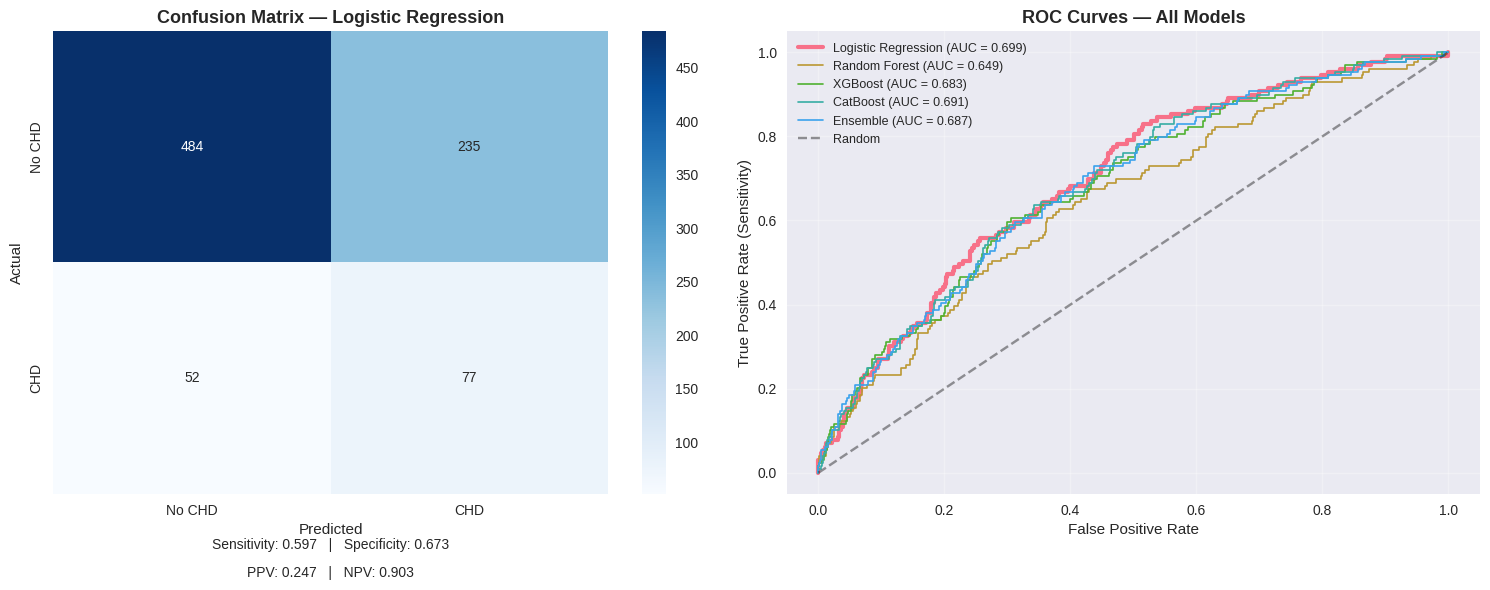

✅ Saved: outputs/11_confusion_roc.png


In [15]:
cm = confusion_matrix(y_test_reset, predictions[primary_model_name])
tn, fp, fn, tp = cm.ravel()

sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
ppv         = tp / (tp + fp) if (tp + fp) > 0 else 0
npv         = tn / (tn + fn) if (tn + fn) > 0 else 0

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ax = axes[0]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No CHD', 'CHD'],
            yticklabels=['No CHD', 'CHD'], ax=ax)
ax.set_title(f'Confusion Matrix — {primary_model_name}',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
ax.text(0.5, -0.12,
        f'Sensitivity: {sensitivity:.3f}   |   Specificity: {specificity:.3f}',
        transform=ax.transAxes, ha='center', fontsize=10)
ax.text(0.5, -0.18,
        f'PPV: {ppv:.3f}   |   NPV: {npv:.3f}',
        transform=ax.transAxes, ha='center', fontsize=10)

ax = axes[1]
for name in models:
    fpr, tpr, _ = roc_curve(y_test_reset, probabilities[name])
    auc = results_df.loc[name, 'ROC-AUC']
    lw  = 3 if name == primary_model_name else 1.2
    ax.plot(fpr, tpr, lw=lw, label=f'{name} (AUC = {auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate (Sensitivity)')
ax.set_title('ROC Curves — All Models', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/11_confusion_roc.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Saved: outputs/11_confusion_roc.png')

### 4.13 Clinical Performance — Primary Model

In [16]:
print('='*60)
print(f'  CLINICAL METRICS — {primary_model_name}')
print('='*60)
print(f'\n  True Positives  (TP): {tp:4d}  CHD correctly identified')
print(f'  True Negatives  (TN): {tn:4d}  No-CHD correctly cleared')
print(f'  False Positives (FP): {fp:4d}  healthy flagged as CHD')
print(f'  False Negatives (FN): {fn:4d}  CHD cases MISSED  ← critical')

print(f'\n  Sensitivity (Recall): {sensitivity:.4f}  — catches {sensitivity*100:.1f}% of CHD cases')
print(f'  Specificity:          {specificity:.4f}  — clears  {specificity*100:.1f}% of healthy patients')
print(f'  PPV (Precision):      {ppv:.4f}  — {ppv*100:.1f}% of CHD predictions correct')
print(f'  NPV:                  {npv:.4f}  — {npv*100:.1f}% of negative predictions correct')
print(f'  ROC-AUC:              {results_df.loc[primary_model_name, "ROC-AUC"]:.4f}')
print(f'  PR-AUC:               {results_df.loc[primary_model_name, "PR-AUC"]:.4f}  ← primary metric')

print()
if sensitivity >= 0.80:
    print(f'   Excellent sensitivity — catches {sensitivity*100:.1f}% of CHD cases')
elif sensitivity >= 0.60:
    print(f'   Good sensitivity — catches {sensitivity*100:.1f}% of CHD cases')
else:
    print(f'    Moderate sensitivity — {(1-sensitivity)*100:.1f}% of CHD cases missed')

if specificity >= 0.70:
    print(f'   Good specificity — clears {specificity*100:.1f}% of healthy patients')
else:
    print(f'    {(1-specificity)*100:.1f}% false alarm rate on healthy patients')
print('='*60)

  CLINICAL METRICS — Logistic Regression

  True Positives  (TP):   77  CHD correctly identified
  True Negatives  (TN):  484  No-CHD correctly cleared
  False Positives (FP):  235  healthy flagged as CHD
  False Negatives (FN):   52  CHD cases MISSED  ← critical

  Sensitivity (Recall): 0.5969  — catches 59.7% of CHD cases
  Specificity:          0.6732  — clears  67.3% of healthy patients
  PPV (Precision):      0.2468  — 24.7% of CHD predictions correct
  NPV:                  0.9030  — 90.3% of negative predictions correct
  ROC-AUC:              0.6992
  PR-AUC:               0.3045  ← primary metric

  ⚠️  Moderate sensitivity — 40.3% of CHD cases missed
  ⚠️  32.7% false alarm rate on healthy patients


### 4.14 Precision-Recall Curves
> Better than ROC-AUC for severely imbalanced data — PR-AUC reflects performance on the minority (CHD) class directly.

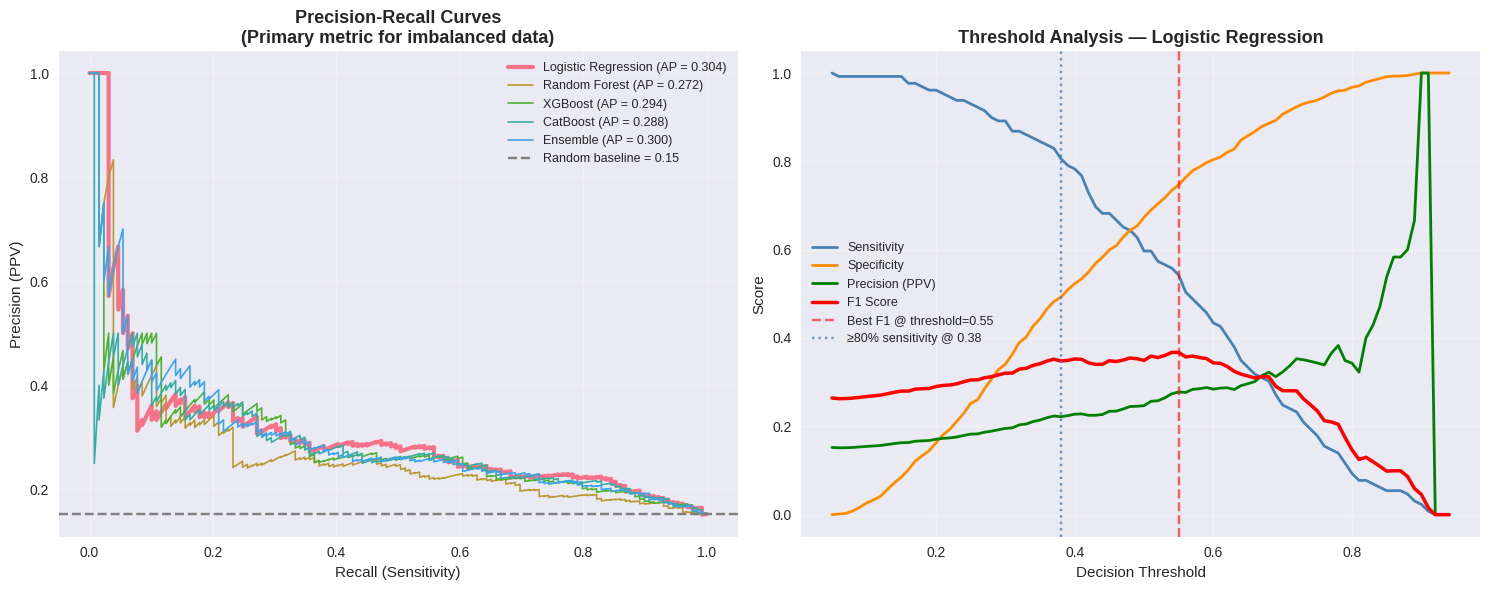

✅ Saved: outputs/12_pr_curves_threshold.png

  Best threshold for F1:  0.55
    F1:          0.3675
    Sensitivity: 0.5426
    Specificity: 0.7469
    PPV:         0.2778


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ax = axes[0]
for name in models:
    prec, rec, _ = precision_recall_curve(y_test_reset, probabilities[name])
    ap = results_df.loc[name, 'PR-AUC']
    lw = 3 if name == primary_model_name else 1.2
    ax.plot(rec, prec, lw=lw, label=f'{name} (AP = {ap:.3f})')

baseline = y_test_reset.mean()
ax.axhline(baseline, color='gray', linestyle='--',
           label=f'Random baseline = {baseline:.2f}')
ax.set_xlabel('Recall (Sensitivity)')
ax.set_ylabel('Precision (PPV)')
ax.set_title('Precision-Recall Curves\n(Primary metric for imbalanced data)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[1]
y_proba_primary = probabilities[primary_model_name]
thresholds = np.arange(0.05, 0.95, 0.01)
sens_list, spec_list, ppv_list, f1_list = [], [], [], []

for t in thresholds:
    yp = (y_proba_primary >= t).astype(int)
    _cm = confusion_matrix(y_test_reset, yp)
    _tn, _fp, _fn, _tp = _cm.ravel()
    sens_list.append(_tp / (_tp + _fn) if (_tp + _fn) > 0 else 0)
    spec_list.append(_tn / (_tn + _fp) if (_tn + _fp) > 0 else 0)
    ppv_list.append(_tp  / (_tp + _fp) if (_tp + _fp) > 0 else 0)
    f1_list.append(f1_score(y_test_reset, yp))

thresh_df = pd.DataFrame({
    'threshold':   thresholds,
    'sensitivity': sens_list,
    'specificity': spec_list,
    'ppv':         ppv_list,
    'f1':          f1_list
})

ax.plot(thresh_df['threshold'], thresh_df['sensitivity'], label='Sensitivity', color='steelblue', lw=2)
ax.plot(thresh_df['threshold'], thresh_df['specificity'], label='Specificity', color='darkorange', lw=2)
ax.plot(thresh_df['threshold'], thresh_df['ppv'],         label='Precision (PPV)', color='green', lw=2)
ax.plot(thresh_df['threshold'], thresh_df['f1'],          label='F1 Score', color='red', lw=2.5)

best_thresh = thresh_df.loc[thresh_df['f1'].idxmax(), 'threshold']
ax.axvline(best_thresh, color='red', linestyle='--', alpha=0.6,
           label=f'Best F1 @ threshold={best_thresh:.2f}')

clin_rows = thresh_df[thresh_df['sensitivity'] >= 0.80]
if len(clin_rows):
    clin_thresh = clin_rows.loc[clin_rows['specificity'].idxmax(), 'threshold']
    ax.axvline(clin_thresh, color='steelblue', linestyle=':', alpha=0.8,
               label=f'≥80% sensitivity @ {clin_thresh:.2f}')

ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Score')
ax.set_title(f'Threshold Analysis — {primary_model_name}',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/12_pr_curves_threshold.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Saved: outputs/12_pr_curves_threshold.png')

best_f1_row = thresh_df.loc[thresh_df['f1'].idxmax()]
print(f'\n  Best threshold for F1:  {best_f1_row["threshold"]:.2f}')
print(f'    F1:          {best_f1_row["f1"]:.4f}')
print(f'    Sensitivity: {best_f1_row["sensitivity"]:.4f}')
print(f'    Specificity: {best_f1_row["specificity"]:.4f}')
print(f'    PPV:         {best_f1_row["ppv"]:.4f}')

---

## Section 5 — SHAP Explainability, Model Export & Deployment Preparation

### 5.1 SHAP Explainer — Logistic Regression (LinearExplainer)
> Using the primary model directly — `shap.LinearExplainer` gives exact SHAP values for linear models. No XGBoost needed.

In [ ]:
shap_sample_size = min(200, len(X_test_prep))
shap_idx = X_test_prep.sample(shap_sample_size, random_state=42).index
X_shap   = X_test_prep.loc[shap_idx].reset_index(drop=True)
y_shap   = y_test_reset.loc[shap_idx].reset_index(drop=True)

explainer    = shap.LinearExplainer(primary_model, X_train_prep)
shap_exp_obj = explainer(X_shap)
shap_values  = shap_exp_obj.values
base_values  = shap_exp_obj.base_values

print(f'SHAP LinearExplainer ready ({primary_model_name})')
print(f'   SHAP values shape: {shap_values.shape}')
print(f'   Base value (mean): {base_values.mean():.4f}')

### 5.2 Global Feature Importance — SHAP Summary (Beeswarm)

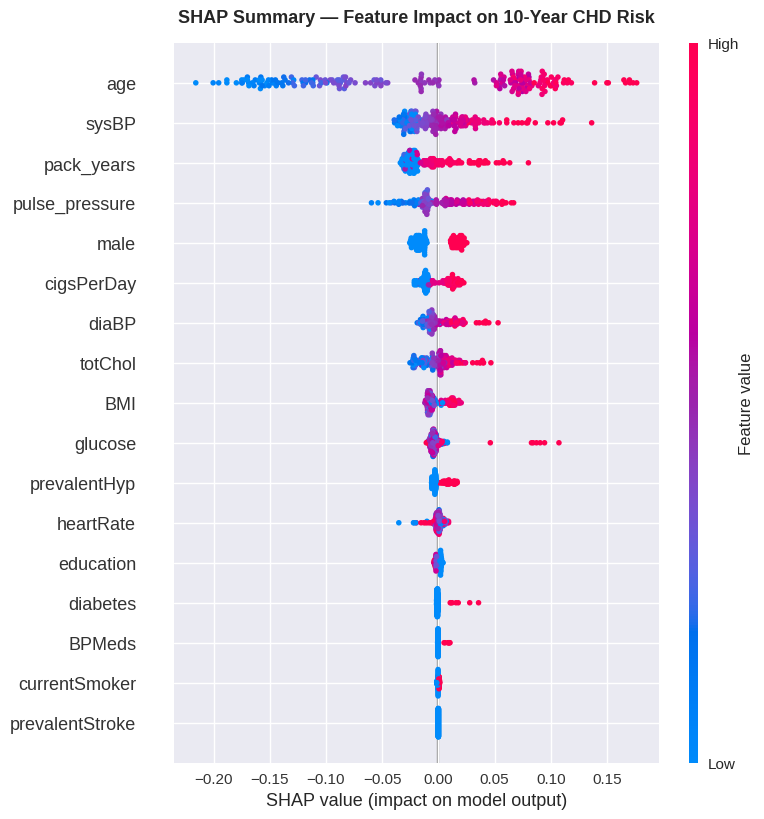

✅ Saved: outputs/13_shap_beeswarm.png


In [19]:
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_shap,
                  feature_names=X_shap.columns, show=False)
plt.title('SHAP Summary — Feature Impact on 10-Year CHD Risk',
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../outputs/13_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Saved: outputs/13_shap_beeswarm.png')

### 5.3 Global Feature Importance — SHAP Bar Chart

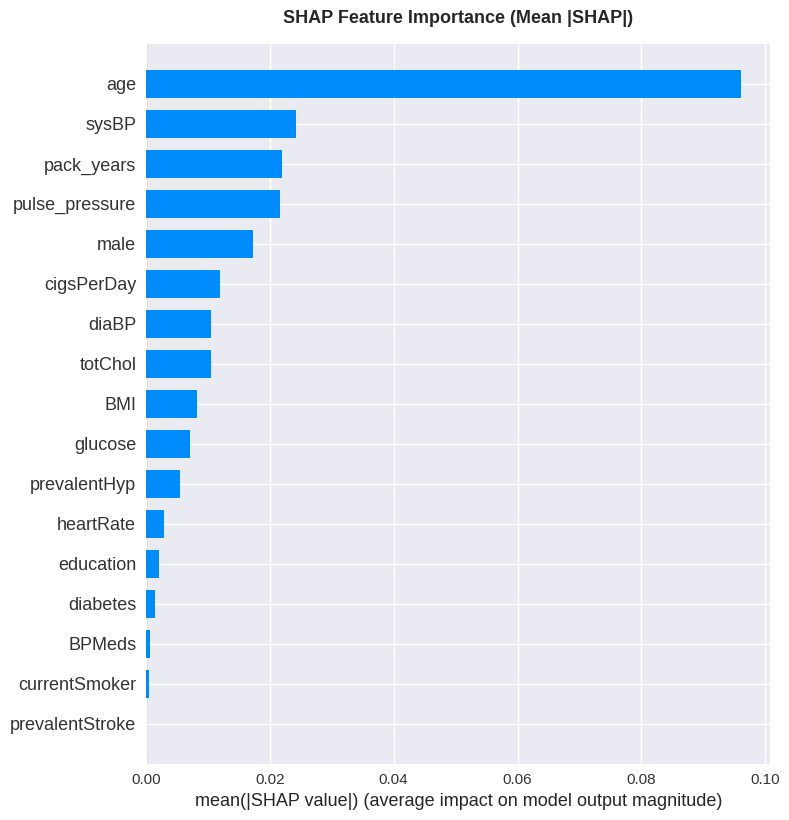

✅ Saved: outputs/14_shap_bar.png


In [20]:
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_shap,
                  feature_names=X_shap.columns,
                  plot_type='bar', show=False)
plt.title('SHAP Feature Importance (Mean |SHAP|)',
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../outputs/14_shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Saved: outputs/14_shap_bar.png')

### 5.4 Top Clinical Features Analysis

In [21]:
feature_importance = pd.DataFrame({
    'Feature': X_shap.columns,
    'Mean_SHAP': np.abs(shap_values).mean(axis=0)
}).sort_values('Mean_SHAP', ascending=False).reset_index(drop=True)

print('Top 10 Features by Mean |SHAP|:\n')
print(feature_importance.head(10).to_string(index=False))

clinical_context = {
    'age':            'Strongest non-modifiable risk factor — CHD risk doubles every decade after 40',
    'sysBP':          'Systolic BP — each +20 mmHg doubles cardiovascular event risk',
    'diaBP':          'Diastolic BP — elevated diastolic indicates arterial stiffness',
    'totChol':        'Total cholesterol — high LDL drives atherosclerotic plaque formation',
    'glucose':        'Fasting glucose — hyperglycaemia accelerates endothelial damage',
    'BMI':            'Obesity marker — excess weight raises BP, glucose, and lipids',
    'cigsPerDay':     'Smoking dose — nicotine promotes clot formation and plaque instability',
    'heartRate':      'Resting heart rate — elevated HR correlates with poor cardiovascular fitness',
    'pulse_pressure': 'Pulse pressure — widened PP indicates arterial stiffness and aortic disease',
    'pack_years':     'Cumulative smoking burden — stronger predictor than current smoker status alone',
    'currentSmoker':  'Active smoking — triples short-term cardiovascular risk',
    'prevalentHyp':   'Established hypertension — leading modifiable risk factor for CHD',
    'diabetes':       'Diabetes — doubles CHD risk, associated with silent ischaemia',
    'male':           'Male sex — testosterone linked to earlier and more aggressive CAD',
    'BPMeds':         'On BP medication — indicates existing hypertension management',
    'prevalentStroke':'Prior stroke — shares pathophysiology with CHD; indicates high vascular risk',
    'education':      'Socioeconomic proxy — lower education linked to higher CHD mortality'
}

print('\nClinical context for top 10 drivers:')
for _, row in feature_importance.head(10).iterrows():
    feat    = row['Feature']
    context = clinical_context.get(feat, 'Cardiovascular risk marker')
    print(f'  {feat:18s} ({row["Mean_SHAP"]:.4f})  —  {context}')

Top 10 Features by Mean |SHAP|:

       Feature  Mean_SHAP
           age   0.096050
         sysBP   0.024187
    pack_years   0.021941
pulse_pressure   0.021597
          male   0.017296
    cigsPerDay   0.011995
         diaBP   0.010517
       totChol   0.010509
           BMI   0.008202
       glucose   0.007142

Clinical context for top 10 drivers:
  age                (0.0960)  —  Strongest non-modifiable risk factor — CHD risk doubles every decade after 40
  sysBP              (0.0242)  —  Systolic BP — each +20 mmHg doubles cardiovascular event risk
  pack_years         (0.0219)  —  Cumulative smoking burden — stronger predictor than current smoker status alone
  pulse_pressure     (0.0216)  —  Pulse pressure — widened PP indicates arterial stiffness and aortic disease
  male               (0.0173)  —  Male sex — testosterone linked to earlier and more aggressive CAD
  cigsPerDay         (0.0120)  —  Smoking dose — nicotine promotes clot formation and plaque instability
  diaB

### 5.5 Individual Patient Explanation — Waterfall Plot

In [ ]:
y_proba_lr_shap = primary_model.predict_proba(X_shap)[:, 1]

high_risk  = np.where((y_shap == 1) & (y_proba_lr_shap > 0.45))[0]
borderline = np.where((y_proba_lr_shap > 0.35) & (y_proba_lr_shap < 0.55))[0]

if len(high_risk):
    idx       = high_risk[0]
    case_type = 'High Risk — Correctly Identified CHD Patient'
elif len(borderline):
    idx       = borderline[0]
    case_type = 'Borderline Case'
else:
    idx       = 0
    case_type = 'Sample Patient'

print(f'Selected: {case_type}  (index {idx})')
print(f'  Actual:         {"CHD" if y_shap.iloc[idx] == 1 else "No CHD"}')
print(f'  Predicted prob: {y_proba_lr_shap[idx]:.3f}')

shap_exp = shap.Explanation(
    values=shap_values[idx],
    base_values=float(base_values[idx]),
    data=X_shap.iloc[idx].values,
    feature_names=list(X_shap.columns)
)

plt.figure(figsize=(12, 8))
shap.plots.waterfall(shap_exp, max_display=14, show=False)
plt.title(f'SHAP Waterfall — {case_type}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/15_shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/15_shap_waterfall.png')

### 5.6 Save Production Artifacts

In [ ]:
print('Saving production artifacts ...\n')

joblib.dump(primary_model, '../artifacts/best_model.pkl')
joblib.dump(preprocessor,  '../artifacts/preprocessor.pkl')
joblib.dump(explainer,     '../artifacts/shap_explainer.pkl')
print(f'best_model.pkl        ({primary_model_name})')
print(f'preprocessor.pkl')
print(f'shap_explainer.pkl')

np.save('../artifacts/shap_values.npy', shap_values)
np.save('../artifacts/patient_shap_example.npy', shap_values[idx])
feature_importance.to_csv('../artifacts/feature_importance.csv', index=False)
print(f'shap_values.npy       ({shap_values.shape[0]} samples)')
print(f'patient_shap_example.npy')
print(f'feature_importance.csv')

with open('../artifacts/feature_names.json', 'w') as f:
    json.dump(feature_names, f, indent=2)

with open('../artifacts/feature_groups.json', 'w') as f:
    json.dump({'continuous': continuous_features, 'categorical': categorical_features}, f, indent=2)

opt_thresh = float(thresh_df.loc[thresh_df['f1'].idxmax(), 'threshold'])
opt_row    = thresh_df.loc[thresh_df['f1'].idxmax()]

metrics_out = {
    'primary_model':     primary_model_name,
    'optimal_threshold': opt_thresh,
    'at_optimal_threshold': {
        'sensitivity': float(opt_row['sensitivity']),
        'specificity': float(opt_row['specificity']),
        'ppv':         float(opt_row['ppv']),
        'f1':          float(opt_row['f1'])
    },
    'at_default_threshold_0.5': {
        'sensitivity': float(sensitivity),
        'specificity': float(specificity),
        'ppv':         float(ppv),
        'npv':         float(npv),
        'roc_auc':     float(results_df.loc[primary_model_name, 'ROC-AUC']),
        'pr_auc':      float(results_df.loc[primary_model_name, 'PR-AUC']),
        'f1_binary':   float(results_df.loc[primary_model_name, 'F1-Score'])
    },
    'all_models': results_df.to_dict(),
    'methodology': {
        'imputation':      'KNNImputer(k=5, distance-weighted)',
        'normalisation':   'PowerTransformer(yeo-johnson)',
        'class_balancing': 'class_weight — no synthetic data',
        'split':           'stratified 80/20 — split before any fitting',
        'tuning':          'Optuna 50 trials per model (XGBoost + CatBoost)',
        'primary_metric':  'PR-AUC + Sensitivity'
    }
}

with open('../artifacts/metrics.json', 'w') as f:
    json.dump(metrics_out, f, indent=2)

results_df.to_csv('../artifacts/model_comparison.csv')
print('metrics.json')
print('model_comparison.csv')
print('\nAll artifacts saved.')

In [24]:
loaded_model  = joblib.load('../artifacts/best_model.pkl')
sample_proba  = loaded_model.predict_proba(X_test_prep.iloc[[0]])[0, 1]

print('\n Artifact validation')
print(f'   Sample prediction (patient 0): {sample_proba:.4f}')
print('\n Notebook complete — all artifacts ready for production')


🔍 Artifact validation
   Sample prediction (patient 0): 0.2712

🎉 Notebook complete — all artifacts ready for production
